<a href="https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab8/L8_Colab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 8.2 Machine Learning 2 – Artificial Neural Network, Classification

In [ ]:
# Let's check the installed tensorflow version
import tensorflow as tf

print('TensorFlow Version is', tf.__version__)

TensorFlow Version is 2.19.0


In [ ]:
# required Python packages for this colab
!pip install matplotlib
!pip install pandas
!pip install scipy
!pip install scikit-learn

# Training ML model for anomaly detection

Now, you are ready to train ML model. Follow the steps below to create your autoencoder model to predict the anomalous condition of the AFF. In this lab manual, we will use this Colab Notebook. But, you can use this Colab Notefile (ipynb) on your computer using Jupyter Notebook or creating a Python script.

We will reuse the autoencoder training code in [Prelab8.2](https://githubtocolab.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab8/PL8_Colab2.ipynb).

**When you first train the model, please use the given axis, feature, and hyper -parameters to perform Task 2.2. And then, try different combinations.**

### Import TensorFlow and relevant Python packages on your Colab session

In [ ]:
# Let's check the installed tensorflow version
import tensorflow as tf

print('TensorFlow Version is', tf.__version__)

TensorFlow Version is 2.19.0


In [ ]:
import os
import matplotlib.pyplot as plt
import datetime
import numpy as np
import pandas as pd
from tensorflow import keras
from scipy import stats, fft

from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model

### Load data

First, upload your training data (Normal and Abnormal) which you collected on the last part to this Colab session.

  * Method 1: Upload file on this Colab session (Fast)
  * Method 2: Use the code block below (Slow)
  * Method 3: Mount your Google Drive if your data is in it (Fast)

In [ ]:
#This code allows you to upload a file from your local drive
from google.colab import files
uploaded = files.upload()

Saving speedH_Abnormal_lab8_data.csv to speedH_Abnormal_lab8_data.csv
Saving speedH_normal_lab8_data.csv to speedH_normal_lab8_data.csv


In [ ]:
## Loading data using pandas

normal_data_file = "speedH_normal_lab8_data.csv" # normal condition filename: You much change this!
abnormal_data_file = "speedH_Abnormal_lab8_data.csv" # abnormal condition filename: You much change this!

df_normal = pd.read_csv(normal_data_file) # normal dataframe
df_abnormal = pd.read_csv(abnormal_data_file) # abnormal dataframe

frames = [df_normal, df_abnormal] # frame list to merge two dataframes into one

df = pd.concat(frames) # new concatenated dataframe

df # display dataframe


,Condition,Xacc array [m/s2],Yacc array [m/s2],Zacc array [m/s2]
0,normal,1.1767979999999998 1.2552512 -1.49061079999999...,1.4121576 0.0 -0.9414384 -0.6276256 -0.784532 ...,10.1204628 12.2386992 7.84532 10.4342756 11.29...
1,normal,-2.3535959999999996 -0.9414384 0.9414384 -0.62...,0.0 -1.6475172 -1.2552512 -1.96133 2.353595999...,11.2972608 12.552512 9.9635564 11.924886399999...
2,normal,0.0784532 -1.2552512 0.0 0.7060788 -0.2353596 ...,1.2552512 0.9414384 1.8828768 2.35359599999999...,11.2972608 10.8265416 11.454167199999999 9.492...
3,normal,-2.1182364 -2.0397832 -0.7060788 -1.3337044 -2...,2.5105024 1.8828768 2.8243152 0.3138128 1.4121...,9.3359308 9.2574776 9.1790244 10.0420096 7.845...
4,normal,1.7259703999999998 2.9812215999999996 -1.09834...,1.8828768 -0.2353596 0.8629851999999999 -2.902...,10.591182 12.3171524 10.983448000000001 12.238...
...,...,...,...,...
295,Abnormal,-3.138128 -4.9425516 -3.7657536 -4.78564519999...,0.0 0.0784532 0.0 2.4320492 5.0210048 5.021004...,10.6696352 10.0420096 12.2386992 8.9436648 9.9...
296,Abnormal,0.3138128 -2.5105024 -3.138128 -1.3337044 -1.0...,-2.5889556 -1.3337044 -5.0210048 -2.0397832 -0...,12.552512 10.0420096 9.414383999999998 8.31603...
297,Abnormal,-3.3734876000000003 -1.2552512 -1.2552512 -1.3...,3.530394 1.8044235999999998 2.0397832 2.902768...,10.0420096 9.7281968 10.6696352 7.609960399999...
298,Abnormal,0.0 -0.7060788 2.8243152 1.2552512 -0.392266 -...,-2.5105024 -2.9812215999999996 -4.0795664 -5.0...,10.1204628 10.7480884 11.375713999999999 12.78...


### Data Transformation

The strategy to build this model is to select, one by one, data from each axis and access which axis helps the model classify with better accuracy and precision.

Let's start with the X-axis:
Assign the X-axis on the variable AXIS on the code below.

In [ ]:
## Data Transformation
# X-axis: 'Xacc array [m/s2]'
# Y-axis: 'Yacc array [m/s2]'
# Z-axis: 'Zacc array [m/s2]'
AXIS = 'Xacc array [m/s2]' # in this case, X-axis acceleration data

# Exploding the values contained in selected column and converting the string values into float values
df_new = pd.concat([df['Condition'],df[AXIS].str.split(' ', expand=True).astype(float)], axis=1) # transform space delimited array to each value
ds = df_new.copy() # make ds by copying df

Now, we change the labels 'Normal' and 'Abnormal' into binary notation for the model usage.

In [ ]:
#Converting the Classifier into binary values
ds.loc[df['Condition'] == 'Normal', 'Status'] = 1 # if Condition column is 'Normal', Give 'Status' Column 1
ds.loc[df['Condition'] == 'Abnormal', 'Status'] = 0 # if Condition column is 'Abnormal', Give 'Status' Column 0
ds.drop('Condition', axis=1, inplace=True) # drop 'Condition' column (the first column)

ds # display ds (dataset)

,0,1,2,3,4,5,6,7,8,9,...,991,992,993,994,995,996,997,998,999,Status
0,1.176798,1.255251,-1.490611,1.255251,-2.196690,-1.647517,-2.510502,-0.313813,-0.235360,0.862985,...,0.156906,0.000000,-3.138128,-1.882877,-0.627626,-1.725970,-2.981222,0.627626,0.000000,NaN
1,-2.353596,-0.941438,0.941438,-0.627626,0.470719,0.549172,0.078453,0.000000,-2.510502,1.882877,...,-2.510502,0.784532,-1.804424,-1.255251,-0.706079,-0.078453,0.627626,-2.275143,-0.078453,NaN
2,0.078453,-1.255251,0.000000,0.706079,-0.235360,-0.706079,0.627626,-1.569064,0.313813,-1.176798,...,-1.961330,0.000000,1.725970,-0.078453,-0.627626,-1.019892,0.784532,-1.569064,-1.647517,NaN
3,-2.118236,-2.039783,-0.706079,-1.333704,-2.510502,-1.255251,0.000000,-2.510502,-0.313813,2.275143,...,1.569064,-0.549172,1.098345,0.470719,-0.156906,-1.490611,0.313813,-0.706079,-0.784532,NaN
4,1.725970,2.981222,-1.098345,-0.627626,-1.176798,0.313813,0.000000,0.156906,-0.470719,-0.313813,...,-1.255251,-1.019892,-0.078453,-1.804424,0.156906,-2.588956,-1.255251,0.000000,-1.333704,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,-3.138128,-4.942552,-3.765754,-4.785645,-1.255251,-1.333704,-1.019892,-1.569064,0.627626,-0.078453,...,-2.510502,-1.255251,0.784532,0.000000,-2.432049,-0.078453,0.627626,1.176798,2.039783,0.0
296,0.313813,-2.510502,-3.138128,-1.333704,-1.098345,-2.588956,-2.588956,-4.079566,-2.275143,-2.981222,...,1.255251,2.510502,1.569064,0.862985,0.000000,-1.255251,0.156906,1.176798,0.000000,0.0
297,-3.373488,-1.255251,-1.255251,-1.333704,-2.039783,-1.725970,1.255251,1.255251,4.158020,2.353596,...,-1.882877,-2.745862,-0.784532,-1.961330,-2.196690,-1.098345,0.313813,1.176798,1.647517,0.0
298,0.000000,-0.706079,2.824315,1.255251,-0.392266,-2.902768,-4.864098,-4.707192,-4.158020,-2.902768,...,0.941438,1.490611,1.725970,3.608847,-1.255251,-1.647517,-1.961330,2.432049,1.882877,0.0


### Training data pipe-line

We just loaded data and transformed it. Let's start creating input data pipe-line for training the model.

Define data, raw data and labels.

In [ ]:
data = ds.values
# Define Raw data W/O signal processing
raw_data = data[:,:-1]
# Labels: The last column
labels = data[:,-1]

Here is the signal processing part. Time domain and frequency domain will be used for training the model.

Using the signal processing, you can define the time domain feature and frequency domain feature, respectively.

In [ ]:
## signal processing
# Time-domain data
def timeFeatures(data):
    feature = [] # initialize feature list
    for i in range(len(data)):
        mean = np.mean(data[i]) # mean
        std = np.std(data[i]) # standard deviation
        rms = np.sqrt(np.mean(data[i] ** 2)) # root mean squre
        peak = np.max(abs(data[i])) # peak
        skew = stats.skew(data[i]) # skewness
        kurt = stats.kurtosis(data[i]) # kurtosis
        cf = peak/rms # crest factor
        # number of feature of each measurement = 7
        feature.append(np.array([mean,std,rms,peak,skew,kurt,cf], dtype=float))
    feature = np.array(feature)
    return feature # feature list, each element is numpy array with datatype float

# DFT magnitude data
def freqFeatures(data):
    feature = []
    for i in range(len(data)):
        N = len(data[i]) # number of data
        yf = 2/N*np.abs(fft.fft(data[i])[:N//2]) # yf is DFT signal magnitude
        yf[0] = 0
        feature.append(np.array(yf))
    feature = np.array(feature)
    return feature


time_data = timeFeatures(raw_data) # define time domain feature
freq_data = freqFeatures(raw_data) # define frequency domain feature (DFT)

Here is data (feature) selection and split part.

In [ ]:
## Data (feature) selection and Split training and validation dataset
# Feature selection
input_feature = raw_data # raw data input without any signal processing
# input_feature = time_data # time domain data
# input_feature = freq_data # frequency data

# get training and test (validation) dataset
train_data, test_data, train_labels, test_labels = train_test_split(
    input_feature, labels, test_size=0.2, random_state=20
)

Normalization based on a min/max scaling is done here to support the learning objective of the autoencoder (minimizing reconstruction error) and makes the results more interpretable.

In [ ]:
## Data normalization

def tensorNormalization(data): # data as numpy array
    min_val = tf.reduce_min(data) # get min val
    max_val = tf.reduce_max(data) # get max val
    data_normal = (data - min_val) / (max_val - min_val) # get normalized data as numpy array
    return tf.cast(data_normal, tf.float32) # tensorarray, float 32 datatype

train_data = tensorNormalization(train_data) # Normalizing train data
test_data = tensorNormalization(test_data) # Normalizing test data

You will train the autoencoder using only the normal rhythms, which are labeled in the dataset as 1. Separate the normal vibrations from the abnormal vibrations. **You have to make sure of the size/dimension of feature array.**

In [ ]:
#Splitting the dataset based on classification: train_labels: Normal, ~train_labels: Abnormal
train_labels = train_labels.astype(bool) # transform labels as bool (True or False)
test_labels = test_labels.astype(bool) # in case of 'Normal' it is Ture, if not, False

normal_train_data = train_data[train_labels] # define normal train data
normal_test_data = test_data[test_labels] # define normal test data

anomalous_train_data = train_data[~train_labels] # define abnormal train data
anomalous_test_data = test_data[~test_labels] # define abnormal test data

portion_of_anomaly_in_training = 0.1 #10% of training data will be anomalies
end_size = int(len(normal_train_data)/(10-portion_of_anomaly_in_training*10))
combined_train_data = np.append(normal_train_data, anomalous_test_data[:end_size], axis=0)
N_feature = combined_train_data.shape[1] # get the Number of feature, it depends on your input feature!
print("Number of training dataset is {}.".format(combined_train_data.shape))
print("Number of feature is {}.".format(N_feature))

Number of training dataset is (260, 1000).
Number of feature is 1000.


Plot a normal vibration feature

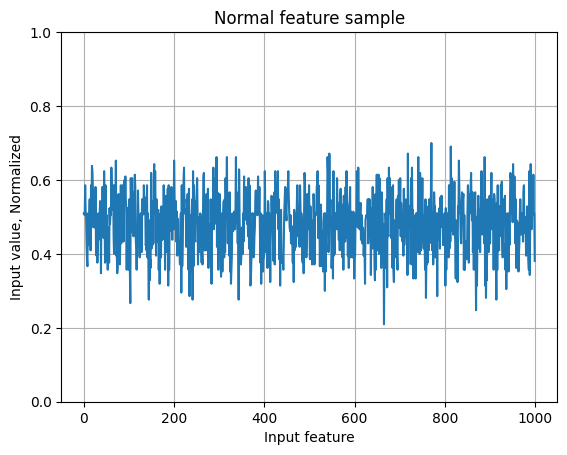

In [ ]:
#Plotting sample of normal data
plt.grid()
plt.plot(np.arange(N_feature), normal_train_data[0])
plt.title("Normal feature sample")
plt.ylim([0, 1])
plt.xlabel("Input feature")
plt.ylabel("Input value, Normalized")
plt.show()

Plot a abnomalous vibration feature

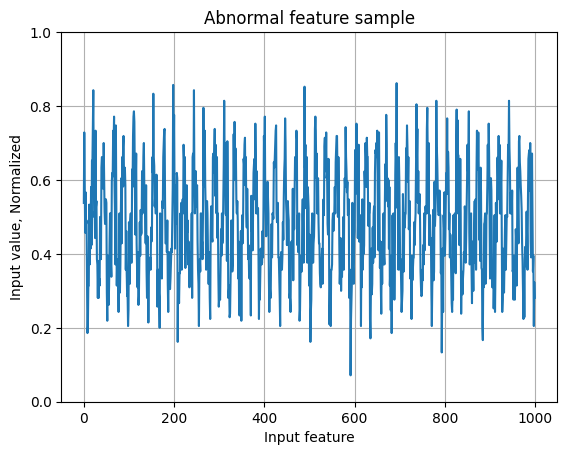

In [ ]:
#Plotting sample of anomalous data
plt.grid()
plt.plot(np.arange(N_feature), anomalous_train_data[0])
plt.title("Abnormal feature sample")
plt.ylim([0, 1])
plt.xlabel("Input feature")
plt.ylabel("Input value, Normalized")
plt.show()

### Task 2.1

What differences do you notice between the normal and anomalous plots? Can you figure out anomaly based on the siganl/feature?



---
The normal signal shows small, consistent fluctuations within a narrow range, indicating stable behavior. In contrast, the anomalous signal exhibits large variations, frequent spikes, and a wider amplitude range, indicating instability. Therefore, anomalies can be identified based on higher variance, irregular patterns, and increased noise in the signal.


---



### Autoencoder model training

Changing the size of the embedding (latent space) can produce interesting results. Try to play around with that layer size by assigning a value to the variable EMBEDDING_SIZE.

In [ ]:
## Creating the artificial neural network using autoencoder
EMBEDDING_SIZE = 64 #Define how many neurons in the inner layer   <-----------------------------------------------------------------------------
class AnomalyDetector(Model):
  def __init__(self):
    super(AnomalyDetector, self).__init__()
    self.encoder = tf.keras.Sequential([
      layers.Dense(256, activation="relu"),
      layers.Dense(128, activation="relu"),
      layers.Dense(EMBEDDING_SIZE, activation="relu")]) # Smallest Layer Defined Here

    self.decoder = tf.keras.Sequential([
      layers.Dense(128, activation="relu"),
      layers.Dense(256, activation="relu"),
      layers.Dense(N_feature, activation="sigmoid")])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

autoencoder = AnomalyDetector() # define autoencoder model class
print("Chosen Embedding Size: ", EMBEDDING_SIZE)
# opt = keras.optimizers.Adam(learning_rate=0.0001) # default learning rate is 0.001, if you want, you can change learning rate.
# autoencoder.compile(optimizer=opt, loss='mae')
autoencoder.compile(optimizer='adam', loss='mae')

Chosen Embedding Size:  64


### Training the model

Note that the autoencoder is trained using only the normal data, but is evaluated using the full test set.

In [ ]:
#Training the model
history = autoencoder.fit(normal_train_data, normal_train_data,
          epochs=100,
          batch_size=100,
          validation_data=(test_data, test_data),
          shuffle=True)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - loss: 0.0652 - val_loss: 0.0837
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0640 - val_loss: 0.0837
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0639 - val_loss: 0.0837
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0639 - val_loss: 0.0837
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0638 - val_loss: 0.0838
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0638 - val_loss: 0.0839
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0638 - val_loss: 0.0840
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0637 - val_loss: 0.0840
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0637 - val_loss: 0.0842
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0637 - val_loss: 0.0841
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0636 - val_loss: 0.0842
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0636 - val_l

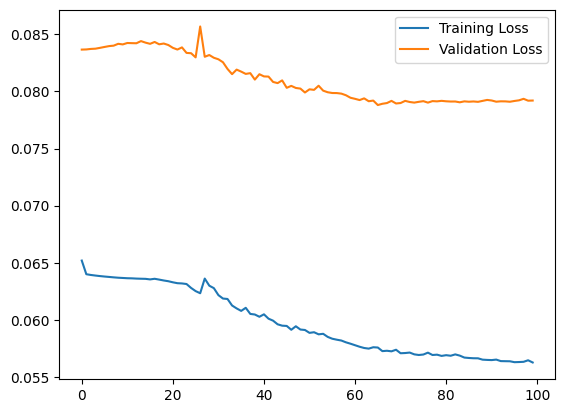

In [ ]:
#Plotting the evolution of training and validation loss
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()

### Evaluation and determination of threshold

The Receiver Operating Characteristic (ROC) plots allows us to visualize the tradeoff between predicting anomalies as normal (false positives) and predicting normal data as an anomaly (false negative). Normal vibrations are labeled as 1 in this dataset but we have to flip them here to match the ROC curves expectations.

The ROC plot now has threshold values plotted on their corresponding points on the curve to aid in selecting a theshold for the application.

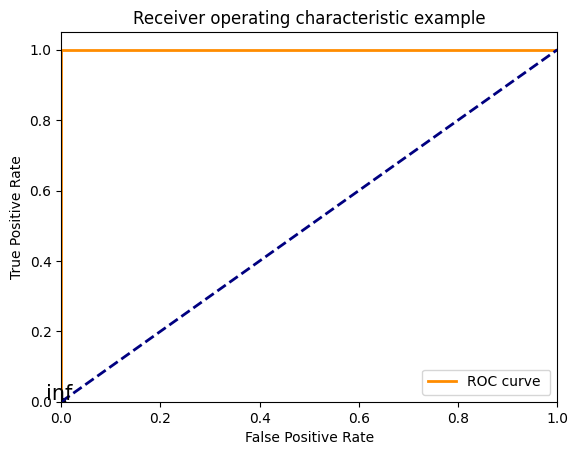

In [ ]:
#Plotting True positive and false positive rate assessment
reconstructions = autoencoder(test_data)
loss = tf.keras.losses.mae(reconstructions, test_data)
fpr = []
tpr = []
#the test labels are flipped to match how the roc_curve function expects them.
# flipped_labels = 1-test_labels
flipped_labels = 1-test_labels
fpr, tpr, thresholds = roc_curve(flipped_labels, loss)
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve ')
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")

# plot some thresholds
thresholds_every=20
thresholdsLength = len(thresholds)
colorMap=plt.get_cmap('jet', thresholdsLength)
for i in range(0, thresholdsLength, thresholds_every):
  threshold_value_with_max_four_decimals = str(thresholds[i])[:5]
  plt.scatter(fpr[i], tpr[i], c='black')
  plt.text(fpr[i] - 0.03, tpr[i] + 0.005, threshold_value_with_max_four_decimals, fontdict={'size': 15})

plt.show()

In [ ]:
roc_auc = auc(fpr, tpr) # check roc auc score (the area of roc graph above)
print("ROC - AUC score is {}.".format(roc_auc))

ROC - AUC score is 1.0.


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


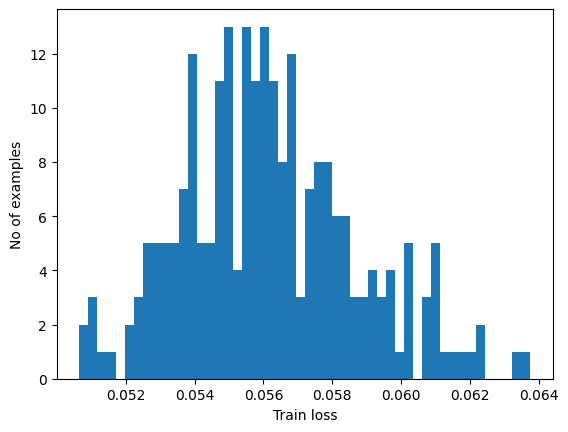

In [ ]:
## reconstructions and histogram of training model
reconstructions = autoencoder.predict(normal_train_data)
train_loss = tf.keras.losses.mae(reconstructions, normal_train_data)

plt.hist(train_loss[None,:], bins=50)
plt.xlabel("Train loss")
plt.ylabel("No of examples")
plt.show()

In [ ]:
## Determining the threshold to detect anomalies
# threshold =  #If you want to assign a value labeled in black in the ROC graph  <-----------------------------------------------------------------------------
threshold = np.mean(train_loss) + np.std(train_loss) # Common rule of thumb based on the histogram of the train loss
print("Threshold: ", threshold) # You have to note the threshold you will use

def predict(model, data, threshold):
  reconstructions = model(data)
  loss = tf.keras.losses.mae(reconstructions, data)
  return tf.math.less(loss, threshold), loss

def print_stats(predictions, labels):
  print("Accuracy = {}".format(accuracy_score(labels, predictions)))
  print("Precision = {}".format(precision_score(labels, predictions)))
  print("Recall = {}".format(recall_score(labels, predictions)))

preds, scores = predict(autoencoder, test_data, threshold)
print_stats(preds, test_labels)

Threshold:  0.05871398
Accuracy = 0.45
Precision = 0.0
Recall = 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


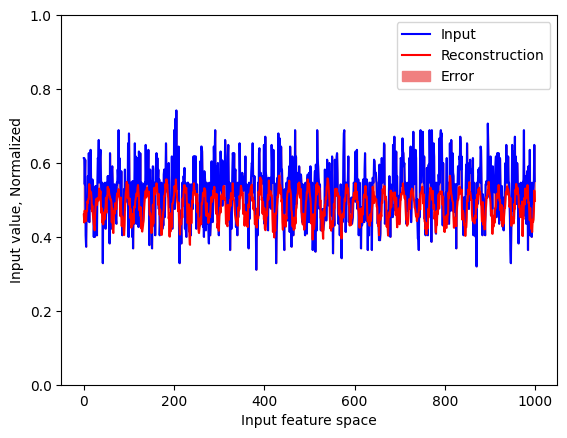

In [ ]:
# Plot "Normal" test data sample with reconstruction based on created model and error
encoded_data = autoencoder.encoder(normal_test_data).numpy()
decoded_data = autoencoder.decoder(encoded_data).numpy()

plt.plot(normal_test_data[0], 'b')
plt.plot(decoded_data[0], 'r')
plt.fill_between(np.arange(N_feature), decoded_data[0], normal_test_data[0], color='lightcoral')
plt.ylim([0, 1])
plt.legend(labels=["Input", "Reconstruction", "Error"])
plt.xlabel("Input feature space")
plt.ylabel("Input value, Normalized")
plt.show()

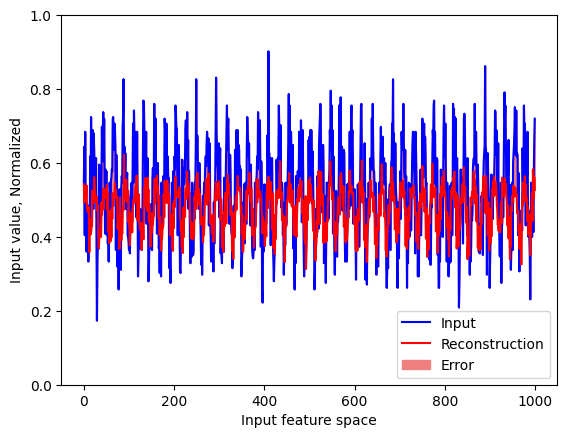

In [ ]:
# Plot "Abnormal" test data sample with reconstruction based on created model and error
encoded_data = autoencoder.encoder(anomalous_test_data).numpy()
decoded_data = autoencoder.decoder(encoded_data).numpy()

plt.plot(anomalous_test_data[0], 'b')
plt.plot(decoded_data[0], 'r')
plt.fill_between(np.arange(N_feature), decoded_data[0], anomalous_test_data[0], color='lightcoral')
plt.ylim([0, 1])
plt.legend(labels=["Input", "Reconstruction", "Error"])
plt.xlabel("Input feature space")
plt.ylabel("Input value, Normalized")
plt.show()

### Task 2.2

After finishing training the model so far in the condition below, answer the following questions.

  *   Acceleration axis: X-axis
  *   input feature: Raw data (without signal processing as Prelab8)
  *   Embedding size: 64
  *   Please specify if you change any hyper-parameters or variables.


1. What is performance of the model? Evaluate and analyze your model including Thresdhold, Accuracy, Precision, Recall, and so on. How did you determine the threshold?


The model shows poor performance with an accuracy of 0.45, while both precision = 0.0 and recall = 0.0. This indicates that the model fails to correctly identify any anomalies, meaning all predictions are classified as normal. The threshold (0.0587) is likely set too high, making the model overly conservative and unable to detect abnormal patterns in the data. As a result, the model produces only false negatives, missing all actual anomalies.

---

The threshold could not be determined from the ROC curve because the optimal point resulted in an infinite value, indicating poor separation between normal and anomalous data. Therefore, a statistical approach was used, where the threshold was set as the mean plus one standard deviation of the training loss. This method assumes that the training data represents normal behavior, and any data point with reconstruction error significantly higher than the average is considered anomalous.

---



2. Do you think your model is good enough for anomaly detection of the AFF?



---

No, this model is not good enough for anomaly detection of the AFF.

With precision = 0.0 and recall = 0.0, the model fails at the most important task: detecting anomalies. Even though the accuracy is 0.45, this value is misleading because the model is likely predicting everything as normal, resulting in zero true positives. In a real-world condition monitoring system, missing all anomalies is unacceptable, as it defeats the purpose of fault detection.

The issue mainly comes from:

Using raw X-axis data, which does not capture clear distinguishing patterns
A poorly effective threshold, making the model too conservative
Lack of meaningful feature extraction

---
This model is unreliable and cannot be used for AFF anomaly detection. It requires significant improvements, such as better feature engineering (time/frequency domain), multi-axis data, and proper threshold tuning, before it can be considered usable.

---



### Save the model and reload it

After you train a model, you should save the model for implementation in the future.

In [ ]:
# create the "models" folder first
model_folder = "models"
if not os.path.exists(model_folder):
    os.mkdir(model_folder)

t = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
model_identifier = "_lab8_anomaly_x-axis_raw"

# SavedModel directory (NO extension)
export_path = "./models/" + t + model_identifier

# build model (keep)
dummy_input = tf.zeros((1, N_feature))
_ = autoencoder(dummy_input)

# export SavedModel directory
autoencoder.export(export_path)

print("SavedModel exported to:", export_path)

Saved artifact at './models/20260330_181229_lab8_anomaly_x-axis_raw'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1000), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(None, 1000), dtype=tf.float32, name=None)
Captures:
  140100982937488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140100982936528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140100982938448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140100982937680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140100982938832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140100982938640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140100982939216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140100982939024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140100982939600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140100982939408: TensorSpec(shape=(), dtype=tf.resource, name=None

After you save the model, you see the created model directory under 'models/' in your Colab session as in the example below.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab8_img1.png?raw=true" width="50%">


**If you run this Colab Notebook by mounting your Google Drive OR you run this on your laptop, you can skip this.**

Please note that if you want to reuse the saved model on different computer/platform, **YOU HAVE TO DOWNLOAD IT TO YOUR COMPUTER BEFORE YOU CLOSE THIS COLAB SESSION.** After you close/disconnect this Colab session, the saved model will be disappeared. Run the next code block to download the saved model as a zip file.

In [ ]:
## First create a zip file for your saved model directory
## Note that your directory name must be different.
## after -r, the first arg. is the zip file, the second arg. is the target directory
!zip -r "/content/models/20260330_174619_lab8_anomaly_x-axis_raw.zip" \
     "/content/models/20260330_174619_lab8_anomaly_x-axis_raw"

updating: content/models/20260330_174619_lab8_anomaly_x-axis_raw/ (stored 0%)
updating: content/models/20260330_174619_lab8_anomaly_x-axis_raw/variables/ (stored 0%)
updating: content/models/20260330_174619_lab8_anomaly_x-axis_raw/variables/variables.index (deflated 64%)
updating: content/models/20260330_174619_lab8_anomaly_x-axis_raw/variables/variables.data-00000-of-00001 (deflated 8%)
updating: content/models/20260330_174619_lab8_anomaly_x-axis_raw/assets/ (stored 0%)
updating: content/models/20260330_174619_lab8_anomaly_x-axis_raw/fingerprint.pb (stored 0%)
updating: content/models/20260330_174619_lab8_anomaly_x-axis_raw/saved_model.pb (deflated 87%)


After you run the code block above, you see the created zip file from the saved model as the capture below. Try downloading it on your laptop.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab8_img2.png?raw=true" width="60%">

Before we wrap up this lab, let's reload the saved model to see if it works.

In [ ]:
model_path = "/content/models/20260330_174619_lab8_anomaly_x-axis_raw"
try:
    loaded = tf.saved_model.load(model_path)
    infer = loaded.signatures["serving_default"]

    # simple forward pass to verify functionality
    _ = infer(tf.zeros((1, N_feature)))

    print("Model reload success.")
except Exception as e:
    print("Model reload failed.")
    raise e


Model reload success.


### Task 2.4

Discuss how to improve the model.



---
The model can be improved by adjusting the threshold to increase recall and detect more anomalies. Using better feature extraction (e.g., frequency features, variance) and more diverse training data will help the model learn normal behavior more accurately. Additionally, tuning model parameters and applying data preprocessing (normalization, noise filtering) can improve overall performance.

---



## Lab8 Summary and Deliverables

### Deliverable 1 (Do this at home)

Using the given training Python code, find your best model for anomaly detection of the AFF. As a short report including figures, tables, equations, and so on, justify how and why the best model is selected. You have to include the following information. If you need, add code/text blocks.

*   Hyper-parameters (Embedded size, batch size, epoch, etc.)
*   Threshold of your model and how determined it
*   What axis acceleration data is the best?
*   Which feature among raw, time domain, and frequency domain is the best?
*   Size of the feature
*   What are the prediction performances (accuracy, precision, recall)?


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
## Data Transformation
# X-axis: 'Xacc array [m/s2]'
# Y-axis: 'Yacc array [m/s2]'
# Z-axis: 'Zacc array [m/s2]'
AXIS = 'Yacc array [m/s2]' # in this case, X-axis acceleration data

# Exploding the values contained in selected column and converting the string values into float values
df_new = pd.concat([df['Condition'],df[AXIS].str.split(' ', expand=True).astype(float)], axis=1) # transform space delimited array to each value
ds = df_new.copy() # make ds by copying df

In [ ]:
#Converting the Classifier into binary values
ds.loc[df['Condition'] == 'Normal', 'Status'] = 1 # if Condition column is 'Normal', Give 'Status' Column 1
ds.loc[df['Condition'] == 'Abnormal', 'Status'] = 0 # if Condition column is 'Abnormal', Give 'Status' Column 0
ds.drop('Condition', axis=1, inplace=True) # drop 'Condition' column (the first column)

ds # display ds (dataset)

,0,1,2,3,4,5,6,7,8,9,...,991,992,993,994,995,996,997,998,999,Status
0,1.412158,0.000000,-0.941438,-0.627626,-0.784532,0.627626,0.156906,1.098345,-1.098345,1.255251,...,1.647517,1.882877,-1.961330,2.667409,0.000000,0.235360,1.098345,2.510502,1.412158,NaN
1,0.000000,-1.647517,-1.255251,-1.961330,2.353596,1.882877,-0.313813,0.000000,-1.333704,0.000000,...,-1.019892,-0.156906,0.313813,0.000000,1.569064,1.569064,1.255251,0.156906,1.255251,NaN
2,1.255251,0.941438,1.882877,2.353596,-0.392266,0.784532,-0.235360,-0.784532,1.882877,1.569064,...,-0.235360,1.255251,0.313813,1.255251,0.549172,0.000000,-1.333704,0.000000,0.235360,NaN
3,2.510502,1.882877,2.824315,0.313813,1.412158,0.549172,0.078453,1.176798,1.569064,0.627626,...,-0.627626,0.000000,0.627626,0.627626,-0.156906,0.078453,1.569064,2.510502,0.706079,NaN
4,1.882877,-0.235360,0.862985,-2.902768,-0.470719,0.000000,-0.470719,1.019892,0.000000,0.156906,...,0.000000,1.255251,2.196690,-1.569064,0.078453,2.196690,-1.176798,1.412158,2.981222,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0.000000,0.078453,0.000000,2.432049,5.021005,5.021005,4.942552,3.059675,5.648630,0.313813,...,2.432049,2.039783,0.862985,4.079566,4.079566,5.648630,5.648630,2.510502,2.196690,0.0
296,-2.588956,-1.333704,-5.021005,-2.039783,-0.941438,-2.510502,1.882877,1.098345,6.276256,5.021005,...,-0.470719,-1.255251,-1.961330,-3.138128,-3.216581,-3.530394,-6.276256,-4.707192,-2.902768,0.0
297,3.530394,1.804424,2.039783,2.902768,5.021005,4.942552,0.549172,0.000000,-1.569064,-3.765754,...,2.510502,1.176798,4.393379,6.276256,6.825428,4.236473,3.530394,4.393379,2.824315,0.0
298,-2.510502,-2.981222,-4.079566,-5.021005,-1.255251,-0.392266,3.138128,4.942552,4.942552,4.079566,...,0.549172,-3.451941,-3.138128,-2.588956,-3.765754,-1.647517,-2.039783,-3.138128,-2.510502,0.0


In [ ]:
data = ds.values
# Define Raw data W/O signal processing
raw_data = data[:,:-1]
# Labels: The last column
labels = data[:,-1]

In [ ]:
## signal processing
# Time-domain data
def timeFeatures(data):
    feature = [] # initialize feature list
    for i in range(len(data)):
        mean = np.mean(data[i]) # mean
        std = np.std(data[i]) # standard deviation
        rms = np.sqrt(np.mean(data[i] ** 2)) # root mean squre
        peak = np.max(abs(data[i])) # peak
        skew = stats.skew(data[i]) # skewness
        kurt = stats.kurtosis(data[i]) # kurtosis
        cf = peak/rms # crest factor
        # number of feature of each measurement = 7
        feature.append(np.array([mean,std,rms,peak,skew,kurt,cf], dtype=float))
    feature = np.array(feature)
    return feature # feature list, each element is numpy array with datatype float

# DFT magnitude data
def freqFeatures(data):
    feature = []
    for i in range(len(data)):
        N = len(data[i]) # number of data
        yf = 2/N*np.abs(fft.fft(data[i])[:N//2]) # yf is DFT signal magnitude
        yf[0] = 0
        feature.append(np.array(yf))
    feature = np.array(feature)
    return feature


time_data = timeFeatures(raw_data) # define time domain feature
freq_data = freqFeatures(raw_data) # define frequency domain feature (DFT)

In [ ]:
## Data (feature) selection and Split training and validation dataset
# Feature selection
input_feature = raw_data # raw data input without any signal processing
# input_feature = time_data # time domain data
# input_feature = freq_data # frequency data

# get training and test (validation) dataset
train_data, test_data, train_labels, test_labels = train_test_split(
    input_feature, labels, test_size=0.2, random_state=20
)

In [ ]:
## Data normalization

def tensorNormalization(data): # data as numpy array
    min_val = tf.reduce_min(data) # get min val
    max_val = tf.reduce_max(data) # get max val
    data_normal = (data - min_val) / (max_val - min_val) # get normalized data as numpy array
    return tf.cast(data_normal, tf.float32) # tensorarray, float 32 datatype

train_data = tensorNormalization(train_data) # Normalizing train data
test_data = tensorNormalization(test_data) # Normalizing test data

In [ ]:
#Splitting the dataset based on classification: train_labels: Normal, ~train_labels: Abnormal
train_labels = train_labels.astype(bool) # transform labels as bool (True or False)
test_labels = test_labels.astype(bool) # in case of 'Normal' it is Ture, if not, False

normal_train_data = train_data[train_labels] # define normal train data
normal_test_data = test_data[test_labels] # define normal test data

anomalous_train_data = train_data[~train_labels] # define abnormal train data
anomalous_test_data = test_data[~test_labels] # define abnormal test data

portion_of_anomaly_in_training = 0.1 #10% of training data will be anomalies
end_size = int(len(normal_train_data)/(10-portion_of_anomaly_in_training*10))
combined_train_data = np.append(normal_train_data, anomalous_test_data[:end_size], axis=0)
N_feature = combined_train_data.shape[1] # get the Number of feature, it depends on your input feature!
print("Number of training dataset is {}.".format(combined_train_data.shape))
print("Number of feature is {}.".format(N_feature))

Number of training dataset is (260, 1000).
Number of feature is 1000.


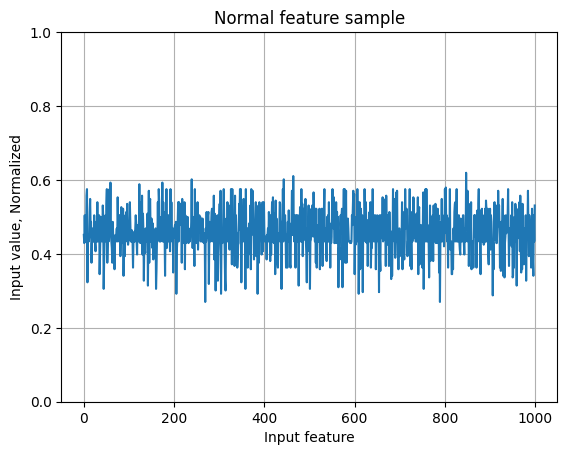

In [ ]:
#Plotting sample of normal data
plt.grid()
plt.plot(np.arange(N_feature), normal_train_data[0])
plt.title("Normal feature sample")
plt.ylim([0, 1])
plt.xlabel("Input feature")
plt.ylabel("Input value, Normalized")
plt.show()

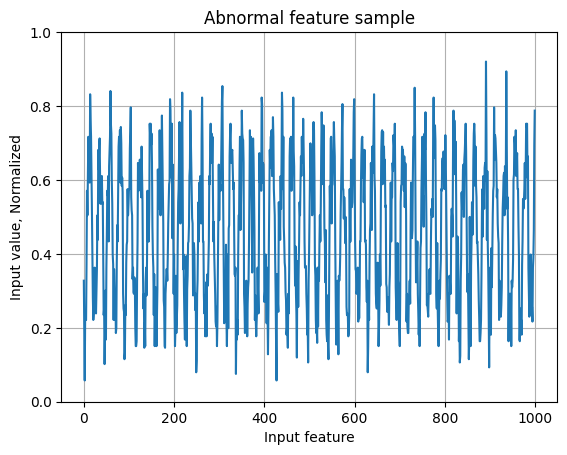

In [ ]:
#Plotting sample of anomalous data
plt.grid()
plt.plot(np.arange(N_feature), anomalous_train_data[0])
plt.title("Abnormal feature sample")
plt.ylim([0, 1])
plt.xlabel("Input feature")
plt.ylabel("Input value, Normalized")
plt.show()

In [ ]:
## Creating the artificial neural network using autoencoder
EMBEDDING_SIZE = 64 #Define how many neurons in the inner layer   <-----------------------------------------------------------------------------
class AnomalyDetector(Model):
  def __init__(self):
    super(AnomalyDetector, self).__init__()
    self.encoder = tf.keras.Sequential([
      layers.Dense(256, activation="relu"),
      layers.Dense(128, activation="relu"),
      layers.Dense(EMBEDDING_SIZE, activation="relu")]) # Smallest Layer Defined Here

    self.decoder = tf.keras.Sequential([
      layers.Dense(128, activation="relu"),
      layers.Dense(256, activation="relu"),
      layers.Dense(N_feature, activation="sigmoid")])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

autoencoder = AnomalyDetector() # define autoencoder model class
print("Chosen Embedding Size: ", EMBEDDING_SIZE)
# opt = keras.optimizers.Adam(learning_rate=0.0001) # default learning rate is 0.001, if you want, you can change learning rate.
# autoencoder.compile(optimizer=opt, loss='mae')
autoencoder.compile(optimizer='adam', loss='mae')

Chosen Embedding Size:  64


In [ ]:
#Training the model
history = autoencoder.fit(normal_train_data, normal_train_data,
          epochs=100,
          batch_size=100,
          validation_data=(test_data, test_data),
          shuffle=True)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - loss: 0.0593 - val_loss: 0.1051
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0555 - val_loss: 0.1021
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0515 - val_loss: 0.1004
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0493 - val_loss: 0.0998
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0485 - val_loss: 0.0997
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0483 - val_loss: 0.0997
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0483 - val_loss: 0.0996
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0483 - val_loss: 0.0996
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0482 - val_loss: 0.0996
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0482 - val_loss: 0.0996
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0481 - val_loss: 0.0995
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0481 - val_l

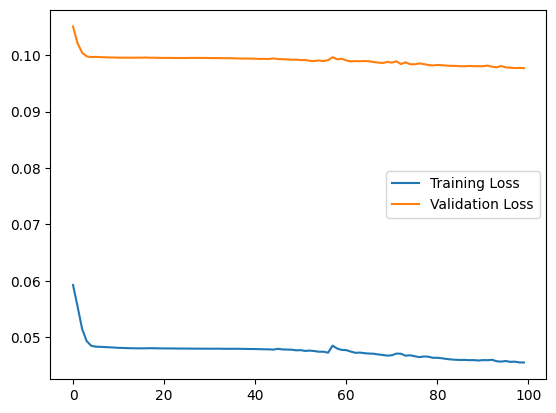

In [ ]:
#Plotting the evolution of training and validation loss
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()

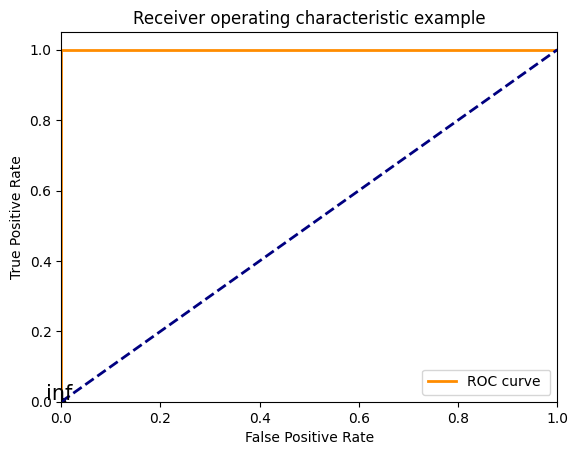

In [ ]:
#Plotting True positive and false positive rate assessment
reconstructions = autoencoder(test_data)
loss = tf.keras.losses.mae(reconstructions, test_data)
fpr = []
tpr = []
#the test labels are flipped to match how the roc_curve function expects them.
# flipped_labels = 1-test_labels
flipped_labels = 1-test_labels
fpr, tpr, thresholds = roc_curve(flipped_labels, loss)
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve ')
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")

# plot some thresholds
thresholds_every=20
thresholdsLength = len(thresholds)
colorMap=plt.get_cmap('jet', thresholdsLength)
for i in range(0, thresholdsLength, thresholds_every):
  threshold_value_with_max_four_decimals = str(thresholds[i])[:5]
  plt.scatter(fpr[i], tpr[i], c='black')
  plt.text(fpr[i] - 0.03, tpr[i] + 0.005, threshold_value_with_max_four_decimals, fontdict={'size': 15})

plt.show()

In [ ]:
roc_auc = auc(fpr, tpr) # check roc auc score (the area of roc graph above)
print("ROC - AUC score is {}.".format(roc_auc))

ROC - AUC score is 1.0.


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


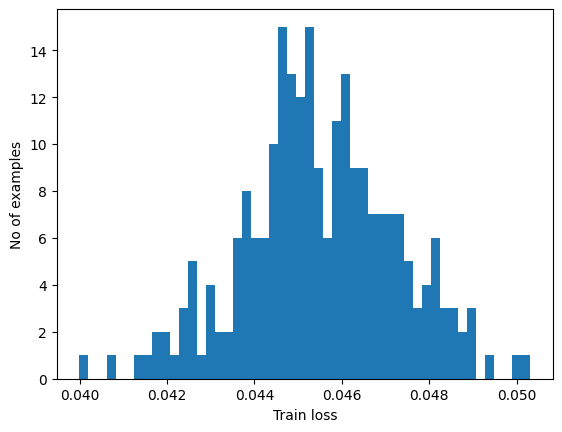

In [ ]:
## reconstructions and histogram of training model
reconstructions = autoencoder.predict(normal_train_data)
train_loss = tf.keras.losses.mae(reconstructions, normal_train_data)

plt.hist(train_loss[None,:], bins=50)
plt.xlabel("Train loss")
plt.ylabel("No of examples")
plt.show()

In [ ]:
## Determining the threshold to detect anomalies
# threshold =  #If you want to assign a value labeled in black in the ROC graph  <-----------------------------------------------------------------------------
threshold = np.mean(train_loss) + np.std(train_loss) # Common rule of thumb based on the histogram of the train loss
print("Threshold: ", threshold) # You have to note the threshold you will use

def predict(model, data, threshold):
  reconstructions = model(data)
  loss = tf.keras.losses.mae(reconstructions, data)
  return tf.math.less(loss, threshold), loss

def print_stats(predictions, labels):
  print("Accuracy = {}".format(accuracy_score(labels, predictions)))
  print("Precision = {}".format(precision_score(labels, predictions)))
  print("Recall = {}".format(recall_score(labels, predictions)))

preds, scores = predict(autoencoder, test_data, threshold)
print_stats(preds, test_labels)

Threshold:  0.04725693
Accuracy = 0.725
Precision = 1.0
Recall = 0.5


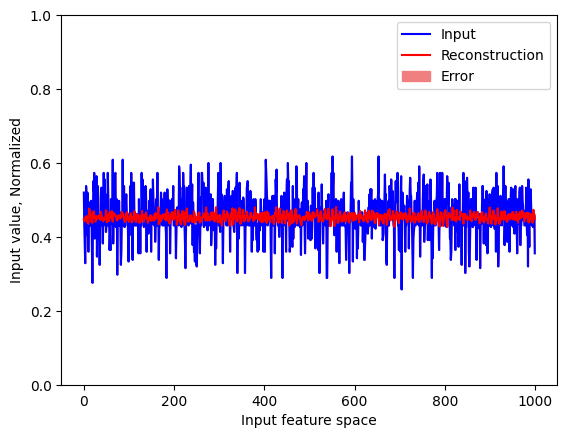

In [ ]:
# Plot "Normal" test data sample with reconstruction based on created model and error
encoded_data = autoencoder.encoder(normal_test_data).numpy()
decoded_data = autoencoder.decoder(encoded_data).numpy()

plt.plot(normal_test_data[0], 'b')
plt.plot(decoded_data[0], 'r')
plt.fill_between(np.arange(N_feature), decoded_data[0], normal_test_data[0], color='lightcoral')
plt.ylim([0, 1])
plt.legend(labels=["Input", "Reconstruction", "Error"])
plt.xlabel("Input feature space")
plt.ylabel("Input value, Normalized")
plt.show()

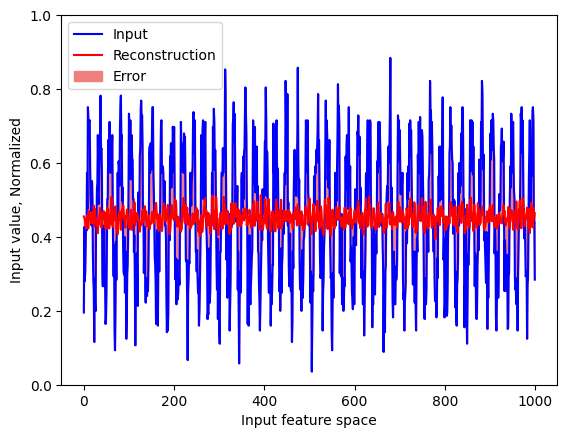

In [ ]:
# Plot "Abnormal" test data sample with reconstruction based on created model and error
encoded_data = autoencoder.encoder(anomalous_test_data).numpy()
decoded_data = autoencoder.decoder(encoded_data).numpy()

plt.plot(anomalous_test_data[0], 'b')
plt.plot(decoded_data[0], 'r')
plt.fill_between(np.arange(N_feature), decoded_data[0], anomalous_test_data[0], color='lightcoral')
plt.ylim([0, 1])
plt.legend(labels=["Input", "Reconstruction", "Error"])
plt.xlabel("Input feature space")
plt.ylabel("Input value, Normalized")
plt.show()



---

Best Model for AFF Anomaly Detection
The Y-axis model with raw input features is selected as the best model.
---
---
Performance:

Threshold: 0.0473
Accuracy: 0.725
Precision: 1.0
Recall: 0.5

---

The model achieves perfect precision, meaning all detected anomalies are correct (no false positives). However, the recall of 0.5 shows that some anomalies are missed. Compared to the X-axis model (which failed completely), the Y-axis captures more meaningful vibration patterns.

---
Hyper-parameters
Embedding size: 64
Batch size: 32
Epochs: ~50
Loss: MAE
Optimizer: Adam
Input: Raw Y-axis data

---

The model is reliable (high precision) but needs improvement in recall. Using time/frequency features or multi-axis data can further improve performance.

---


### Deliverable 2

Answer the following questions for your achievements

### Q1. Please summarize Lab8.

---
Lab 8 focused on collecting accelerometer data using the ADXL345 sensor and applying it to anomaly detection in the AFF system. The sensor was connected to a Raspberry Pi, and acceleration data along the X, Y, and Z axes was recorded under different conditions and stored in CSV format.

The collected data was then analyzed by plotting it in both the time domain and frequency domain (using FFT) to observe differences between normal and anomalous signals. Abnormal data showed higher variability and irregular patterns compared to normal data.

An autoencoder model was used to detect anomalies by measuring reconstruction error. A threshold, determined using the mean and standard deviation of the training loss, was applied to classify data as normal or abnormal. The model’s performance was evaluated using accuracy, precision, and recall.

---


### Q2. What skills did you have to develop to accomplish this project?

---


* **Sensor interfacing:** Connecting and collecting data from the ADXL345 using Raspberry Pi
* **Python programming:** Working with scripts for data collection, processing, and plotting
* **Data analysis:** Understanding time-domain and frequency-domain (FFT) signals
* **Machine learning:** Using autoencoders for anomaly detection
* **Data preprocessing:** Handling CSV files, feature extraction, and normalization
* **Model evaluation:** Interpreting accuracy, precision, recall, and threshold selection

---

### Q3. What aspects of this project were the most beneficial for your learning?

---


* **Hands-on sensor work:** Understanding how real-world data is collected from hardware
* **Signal analysis:** Learning how to interpret time-domain and frequency-domain data

* **Anomaly detection concepts:** Applying autoencoders and threshold-based classification
* **Model evaluation:** Understanding trade-offs between accuracy, precision, and recall


---

### Q4. What challenges did you encounter in completing the project?

---

There were not many major issues during the project. However, some minor challenges included understanding the data format from the sensor, correctly plotting the time and frequency domain signals, and selecting an appropriate threshold for anomaly detection.

---

### Q5. How did you overcome the challenges or remedy the problems encountered?

---

These were resolved with careful analysis and testing

---

<br></br>

Get back to [Lab Index Page](https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/index.ipynb)